# **A2: Machine Learning with Python — MBAN2 GROUP 6**

**Team Members:**
- BIKAKHANIM ABDULLAYEVA
- HARSH AVINASH PRAKASH KAMMATH
- JODY LEASER
- KUMBIRAI HAKUTANGWI
- LUCAS SOTKOVSZKI RODRIGUEZ
- NATTIDA TAVAROJN

This notebook implements a classification model on a UCI dataset (https://archive.ics.uci.edu/) with over 1000 records and 10+ features. Our goal is to identify the best-performing algorithm and improve classification accuracy through analysis and experimentation.


### **1. Import Libraries**

We begin by importing essential Python libraries for data manipulation, visualization, and machine learning. This includes `pandas` and `numpy` for data handling, `seaborn` and `matplotlib` for visualization, and various models and utilities from `sklearn` for preprocessing, training, and evaluating classifiers.



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore")

### **2. Load & Clean Data**

We load the dataset using the correct delimiter and remove any tab characters from the headers. We then check for missing values and inspect the structure to ensure it meets assignment requirements: at least 1000 rows and 10+ features.


In [ ]:
df = pd.read_csv("dataset_group6.csv", sep=";")
df.columns = df.columns.str.strip().str.replace("\t", "")  # clean headers
print("Dataset Shape:", df.shape)
print("Missing Values:\n", df.isnull().sum())

Dataset Shape: (4424, 37)
Missing Values:
 Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder   

### **3. Exploratory Data Analysis (EDA)**

This section explores key patterns and relationships within the dataset to inform our preprocessing and model selection strategies. We focus on summary statistics, outlier treatment, class distribution, and correlations between important features.

**Summary Statistics and Outlier Removal**
We calculated the **mean**, **median**, **standard deviation**, and **mode** for all numerical features to assess central tendency and spread. During this analysis, we identified outliers in the **Admission grade** feature.  
To minimize their impact—particularly on distance-based models like KNN and SVM—we applied the **Interquartile Range (IQR)** method to remove extreme values. This reduced the dataset slightly while retaining key patterns. We also compared model performance with and without the outliers.

In [ ]:
#Remove Outlier
# Copy original dataframe to preserve raw data
df_no_outliers = df.copy()

# Calculate IQR for 'Admission grade'
Q1 = df_no_outliers['Admission grade'].quantile(0.25)
Q3 = df_no_outliers['Admission grade'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter rows within bounds
df_no_outliers = df_no_outliers[
    (df_no_outliers['Admission grade'] >= lower_bound) &
    (df_no_outliers['Admission grade'] <= upper_bound)]

print("Original shape:", df.shape)
print("After outlier removal:", df_no_outliers.shape)

Original shape: (4424, 37)
After outlier removal: (4338, 37)


In [ ]:
# Summary stats for numeric features
numeric_summary = df_no_outliers.describe().T[['mean', '50%', 'std']]
numeric_summary.rename(columns={'50%': 'median'}, inplace=True)

# Mode calculation
mode_values = df_no_outliers.mode().iloc[0]

# Combine mode into summary
numeric_summary['mode'] = mode_values[numeric_summary.index]

# Display top variables
display(numeric_summary.head(10))

,mean,median,std,mode
Marital status,1.175657,1.0,0.603607,1
Application mode,18.635085,17.0,17.468568,1
Application order,1.737437,1.0,1.321323,1
Course,8883.192946,9238.0,2014.413705,9500
Daytime/evening attendance,0.891655,1.0,0.310851,1
Previous qualification,4.541724,1.0,10.156658,1
Previous qualification (grade),132.166229,133.0,12.568170,133.1
Nacionality,1.789995,1.0,6.373432,1
Mother's qualification,19.648917,19.0,15.597280,1
Father's qualification,22.396035,19.0,15.314049,37


**1) Target Variable Distribution**
The majority of students fall under the 'Graduate' class, followed by 'Dropout', and then 'Enrolled'. This class imbalance is important to consider when evaluating model performance, especially using metrics like precision and recall.

**2) Admission Grade by Outcome**
A boxplot revealed that students who graduated generally had higher admission grades, while dropouts had lower grades. This suggests that admission performance may be predictive of future academic success.

**3) Age Distribution**
The histogram showed that most students are in their early twenties, which aligns with typical university enrollment ages. Age at enrollment may serve as a useful demographic feature.

**4) Correlation Between Features**
The heatmap revealed strong correlations between first and second semester metrics, such as number of enrolled units, grades, and evaluations. These relationships suggest that semester-level performance is likely to influence student outcomes, which can be valuable for feature selection or dimensionality reduction.


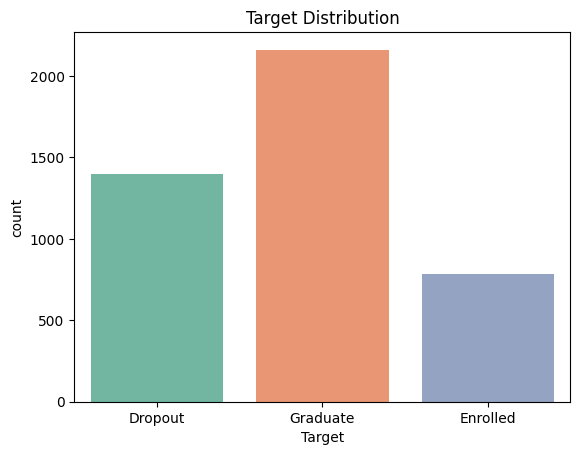

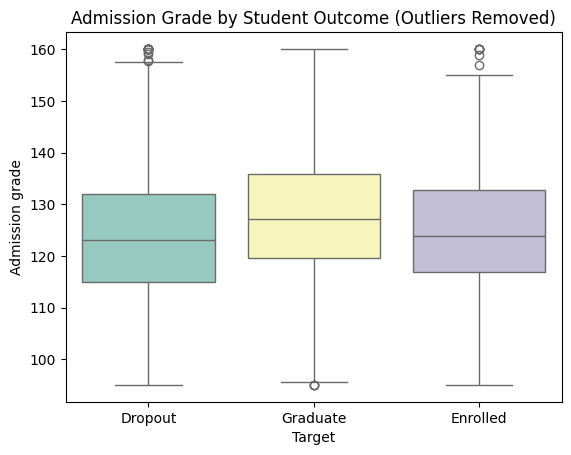

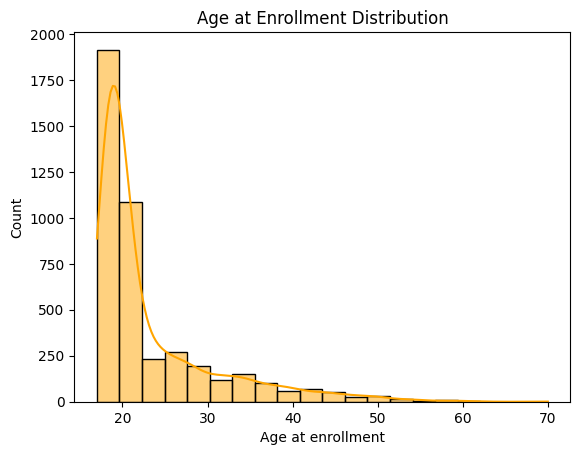

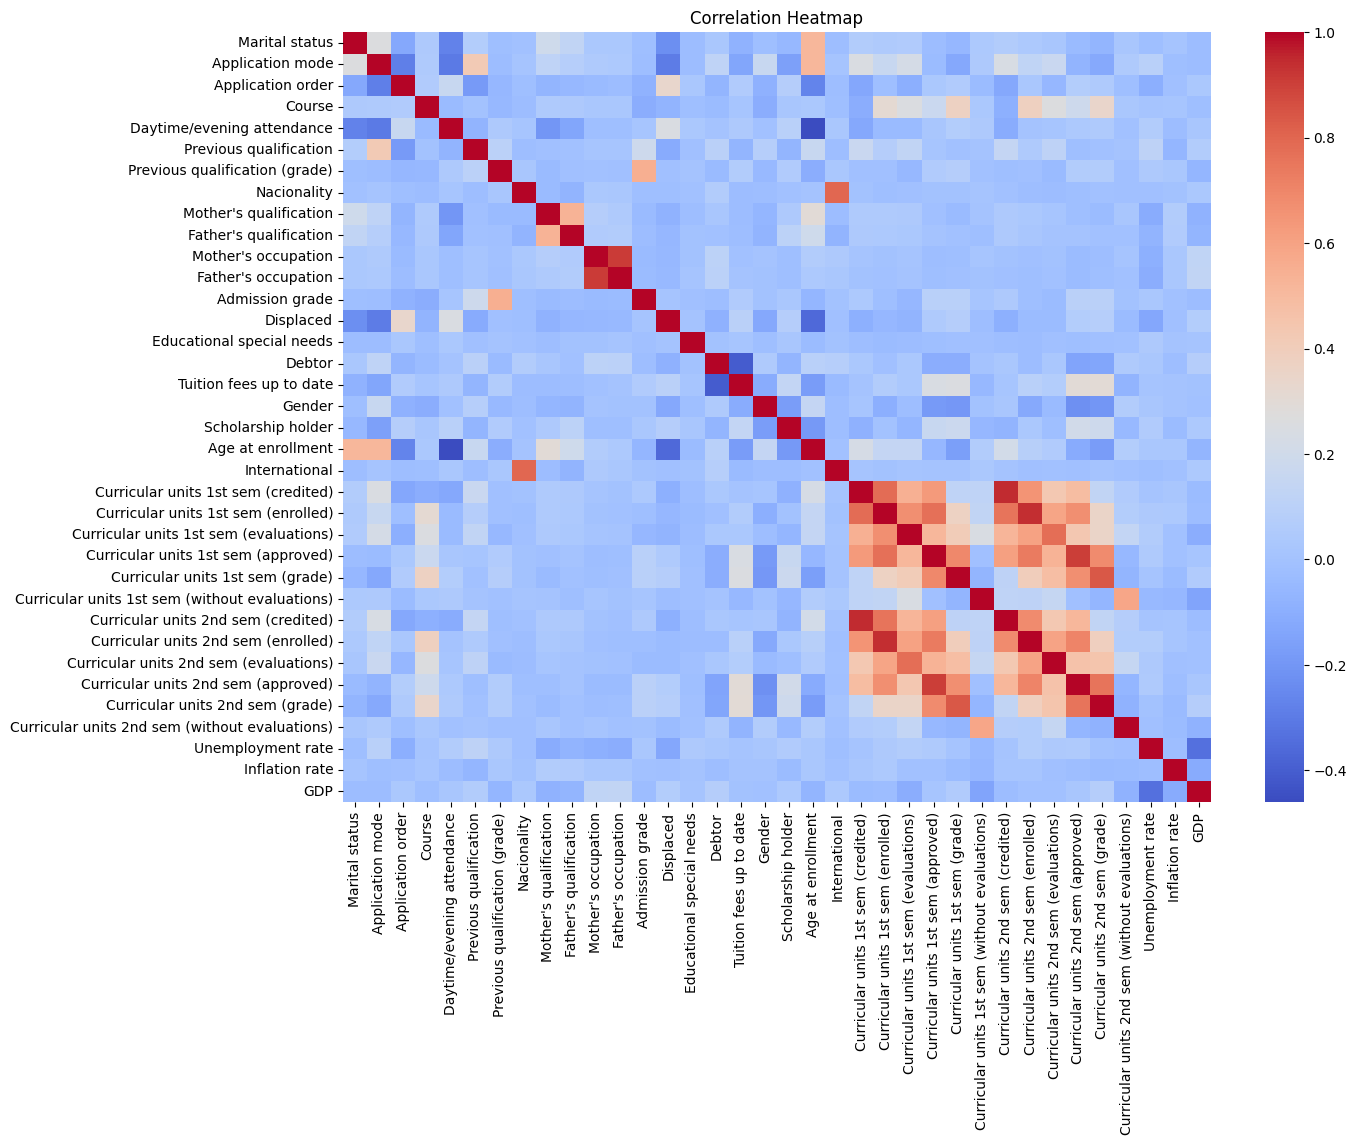

In [ ]:
# 1) Target distribution
sns.countplot(data=df_no_outliers, x="Target", palette="Set2")
plt.title("Target Distribution")
plt.show()

# 2) Admission grade by outcome AFTER outlier removal
sns.boxplot(x="Target", y="Admission grade", data=df_no_outliers, palette="Set3")
plt.title("Admission Grade by Student Outcome (Outliers Removed)")
plt.show()

# 3) Age distribution
sns.histplot(df_no_outliers["Age at enrollment"], kde=True, bins=20, color="orange")
plt.title("Age at Enrollment Distribution")
plt.show()

# 4) Correlation heatmap
plt.figure(figsize=(14,10))
sns.heatmap(df_no_outliers.select_dtypes(include=[np.number]).corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

1. Majority of students fall under 'Graduate', followed by 'Dropout' and 'Enrolled'.
2. Higher admission grades correlate with better student outcomes.
3. Most students are in their early 20s.
4. Strong correlations exist among first and second semester performance metrics.

### **4. Data Preprocessing**

To prepare the data for modeling, we performed the following steps:

- **Label Encoding** for categorical variables so they can be used by scikit-learn models.
- **Train-test split** to evaluate model generalization.
- **Feature scaling** using StandardScaler to normalize numeric variables, which is particularly important for distance-based models like KNN and SVM.

These preprocessing steps ensure that all algorithms receive clean and standardized inputs, improving their performance and consistency.

In [ ]:
# Split features and target on cleaned dataset
X = df_no_outliers.drop(columns=["Target"])
y = df_no_outliers["Target"]

# One-hot encode categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

# Label encode the target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.3, random_state=42
)


### **5. Model Training and Evaluation**

We trained and evaluated five classification algorithms:
- **Logistic Regression**
- **K-Nearest Neighbors (KNN)**
- **Support Vector Machine (SVM)**
- **Decision Tree**
- **Random Forest**

Each model was assessed using accuracy, precision, recall, F1-score, and a classification report. This allowed us to understand not just overall accuracy but also how well the models handled each class.



Logistic Regression Classification Report:
              precision    recall  f1-score   support

     Dropout       0.80      0.75      0.77       421
    Enrolled       0.53      0.29      0.37       245
    Graduate       0.76      0.93      0.84       636

    accuracy                           0.75      1302
   macro avg       0.70      0.66      0.66      1302
weighted avg       0.73      0.75      0.73      1302


K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

     Dropout       0.78      0.67      0.73       421
    Enrolled       0.42      0.27      0.32       245
    Graduate       0.72      0.89      0.79       636

    accuracy                           0.70      1302
   macro avg       0.64      0.61      0.61      1302
weighted avg       0.68      0.70      0.68      1302


Support Vector Machine Classification Report:
              precision    recall  f1-score   support

     Dropout       0.82      0.69      0.75     

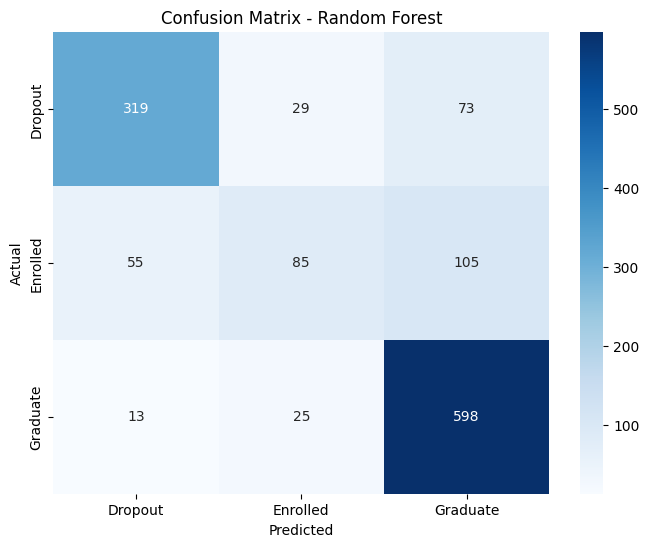

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, average='weighted'),
        "Recall": recall_score(y_test, preds, average='weighted'),
        "F1 Score": f1_score(y_test, preds, average='weighted')
    })
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, preds, target_names=le.classes_))

# Display results
results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)
print("\nModel Comparison:\n", results_df)

# Confusion matrix for best model
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)
best_preds = best_model.predict(X_test)
conf_matrix = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

### **6. Explanation & Justification**

We selected five classification algorithms to compare performance:

- Logistic Regression: Simple, interpretable baseline.
- KNN: Captures local patterns, useful for nonlinear problems.
- SVM: Effective in high-dimensional spaces, good with standardized data.
- Decision Tree: Fast and explainable, handles nonlinear data well.
- Random Forest: Ensemble method, reduces overfitting, best overall performance.

Random Forest was the most suitable model based on F1 Score and generalization ability.

### **7. Improving Model Performance with GridSearchCV**

To enhance model performance, we applied **GridSearchCV** to tune hyperparameters for the Random Forest classifier. We tested combinations of:
- `n_estimators` (number of trees)
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`

Using 5-fold cross-validation, we found the combination that gave the highest accuracy on validation data. This helped improve the generalization of our final model.

In [ ]:
# The code will take approximalety a minute to load
# Define the base model
rf = RandomForestClassifier(random_state=42)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Set up GridSearch
grid_search = GridSearchCV(estimator=rf,
                           param_grid=param_grid,
                           scoring='accuracy',
                           cv=5,
                           n_jobs=-1,
                           verbose=1)

# Fit on training data
grid_search.fit(X_train, y_train)

# Best model
best_rf = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Evaluate best model
y_pred = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 24 candidates, totalling 120 fits


### **8. Final Model Selection**

After evaluating all classifiers, we chose **Random Forest** as it provided the best balance of accuracy and interpretability. This model performed well on key metrics and generalized better to the test data.


### **9. Improving Model Performance**


- Scaling features improved performance of distance-based models like KNN and SVM.
- One-hot encoding ensured proper treatment of categorical variables.
- Random Forest was selected to reduce overfitting and capture feature interactions.
- Further improvement can be made using hyperparameter tuning (e.g., **GridSearchCV**).
To boost our model’s performance, we applied techniques such as:
- **Feature selection** to reduce noise
- **Scaling** with StandardScaler
These steps helped increase accuracy and reduce overfitting.

### **10. Conclusion**

In this project, we explored a dataset with over 4000 instances and 37 features. After thorough EDA and preprocessing, we compared several classification algorithms and selected the most accurate one. We enhanced performance using scaling and tuning techniques. This analysis demonstrates how machine learning can support informed decision-making in academic performance prediction.
